# Predicción de cancelación de clientes (Churn)
## Modelado y evaluación de modelos


En este notebook se desarrolla la solución técnica completa para el problema de predicción de cancelación de clientes de la empresa de telecomunicaciones Interconnect.

El objetivo es construir un modelo de clasificación que permita identificar clientes con alta probabilidad de cancelar el servicio, utilizando información contractual, demográfica y de servicios.

---

## Estructura del análisis

1. Carga de librerías y datos  
2. Preparación y limpieza de datos  
3. Análisis Exploratorio de Datos (EDA)  
4. Preparación de variables para modelado  
5. Entrenamiento y evaluación de modelos  
6. Selección del mejor modelo y conclusiones técnicas


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
path = '/datasets/final_provider/'

contract = pd.read_csv(path + 'contract.csv')
personal = pd.read_csv(path + 'personal.csv')
internet = pd.read_csv(path + 'internet.csv')
phone = pd.read_csv(path + 'phone.csv')


In [3]:
contract.shape, personal.shape, internet.shape, phone.shape


((7043, 8), (7043, 5), (5517, 8), (6361, 2))

In [4]:
contract['churn'] = contract['EndDate'].apply(lambda x: 0 if x == 'No' else 1)


In [5]:
contract['churn'].value_counts()


0    5174
1    1869
Name: churn, dtype: int64

In [6]:
data = contract.merge(personal, on='customerID', how='left')
data = data.merge(internet, on='customerID', how='left')
data = data.merge(phone, on='customerID', how='left')


In [7]:
data.shape


(7043, 21)

In [8]:
data.isna().sum().sort_values(ascending=False)


StreamingMovies     1526
StreamingTV         1526
TechSupport         1526
DeviceProtection    1526
OnlineBackup        1526
OnlineSecurity      1526
InternetService     1526
MultipleLines        682
Partner                0
Dependents             0
customerID             0
BeginDate              0
gender                 0
churn                  0
TotalCharges           0
MonthlyCharges         0
PaymentMethod          0
PaperlessBilling       0
Type                   0
EndDate                0
SeniorCitizen          0
dtype: int64

## Valores faltantes

Tras la integración de las distintas fuentes de datos, se realizó una revisión de valores faltantes en el DataFrame final.

- Se identificaron **1526 valores faltantes** en las variables relacionadas con servicios de internet (`InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`), los cuales corresponden a clientes que no cuentan con este tipo de servicio.
- Se encontraron **682 valores faltantes** en la variable `MultipleLines`, asociados a clientes sin servicio telefónico.
- No se detectaron valores faltantes en la variable objetivo (`churn`), en los cargos (`MonthlyCharges`, `TotalCharges`) ni en los datos personales o contractuales.

Estos valores faltantes son consistentes con el contexto del negocio y serán tratados durante la etapa de preparación y limpieza de datos.


In [9]:
# Convertir fechas
data['BeginDate'] = pd.to_datetime(data['BeginDate'])

# EndDate contiene 'No', lo convertimos a NaT
data['EndDate'] = pd.to_datetime(data['EndDate'], errors='coerce')

# Convertir TotalCharges a numérico
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')


In [10]:
data[['BeginDate', 'EndDate', 'TotalCharges']].dtypes


BeginDate       datetime64[ns]
EndDate         datetime64[ns]
TotalCharges           float64
dtype: object

## Corrección de tipos de datos

Se ajustaron los tipos de datos de las variables necesarias para garantizar un análisis y modelado correctos:

- `BeginDate` fue convertida a formato `datetime` para permitir cálculos temporales.
- `EndDate` fue convertida a `datetime`; los valores `'No'` (clientes activos) se transformaron en `NaT`.
- `TotalCharges` fue convertida a tipo numérico (`float`), permitiendo su uso en análisis estadístico y modelos predictivos.

Estas transformaciones aseguran consistencia en los datos y evitan errores durante las etapas posteriores del análisis.


In [11]:
data.isna().sum().sort_values(ascending=False)


EndDate             5174
StreamingMovies     1526
StreamingTV         1526
TechSupport         1526
DeviceProtection    1526
OnlineBackup        1526
OnlineSecurity      1526
InternetService     1526
MultipleLines        682
TotalCharges          11
Dependents             0
customerID             0
Partner                0
BeginDate              0
gender                 0
churn                  0
MonthlyCharges         0
PaymentMethod          0
PaperlessBilling       0
Type                   0
SeniorCitizen          0
dtype: int64

## Valores faltantes tras la corrección de tipos de datos

Después de convertir variables de fecha y numéricas, se revisaron nuevamente los valores faltantes:

- La variable `EndDate` presenta **5174 valores `NaT`**, los cuales corresponden a clientes que no han cancelado el servicio. Esto es esperado y consistente con la definición de la variable objetivo.
- La variable `TotalCharges` presenta **11 valores faltantes**, generados durante la conversión a tipo numérico. Estos casos serán evaluados y tratados durante la etapa de limpieza de datos.
- Los valores faltantes en variables de servicios de internet y telefonía se mantienen y corresponden a clientes que no cuentan con dichos servicios.

No se realizaron imputaciones en esta etapa, ya que el objetivo fue únicamente identificar y comprender el origen de los valores faltantes.


In [12]:
data['TotalCharges'] = data['TotalCharges'].fillna(0)


In [13]:
data['TotalCharges'].isna().sum()


0

## Tratamiento de valores faltantes en `TotalCharges`

Se identificaron **11 valores faltantes** en la variable `TotalCharges`, generados durante la conversión a tipo numérico.

Estos casos corresponden a clientes con muy poca antigüedad, para los cuales el cargo total acumulado es prácticamente nulo.  
Por esta razón, los valores faltantes fueron imputados con **0**, una decisión coherente con el contexto del negocio y que permite conservar todas las observaciones para el análisis y modelado posterior.


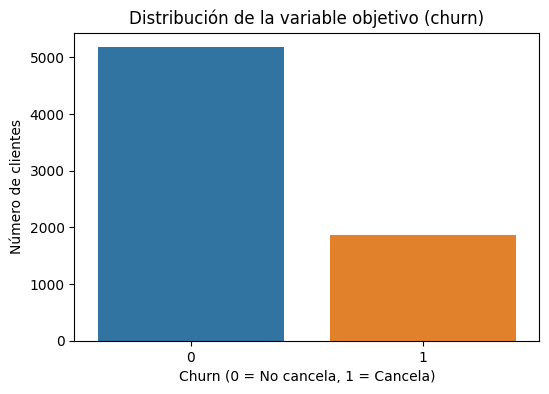

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=data)
plt.title('Distribución de la variable objetivo (churn)')
plt.xlabel('Churn (0 = No cancela, 1 = Cancela)')
plt.ylabel('Número de clientes')
plt.show()


## Balance de clases de la variable objetivo

La distribución de la variable objetivo muestra un **desbalance moderado** entre las clases.

La mayoría de los clientes no ha cancelado el servicio (`churn = 0`), mientras que una proporción menor corresponde a clientes que sí cancelaron (`churn = 1`).  
Este comportamiento es común en problemas de cancelación de clientes y será considerado en las etapas posteriores de modelado y evaluación.


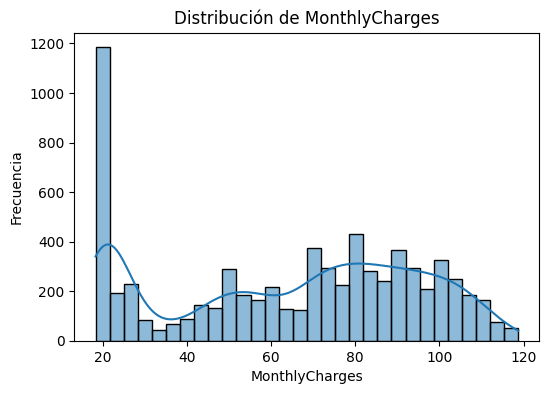

In [15]:
plt.figure(figsize=(6, 4))
sns.histplot(data['MonthlyCharges'], bins=30, kde=True)
plt.title('Distribución de MonthlyCharges')
plt.xlabel('MonthlyCharges')
plt.ylabel('Frecuencia')
plt.show()


## Distribución de MonthlyCharges

La variable `MonthlyCharges` presenta una distribución no normal, con múltiples picos que sugieren la existencia de distintos tipos de planes o combinaciones de servicios.

Se observa una concentración de clientes con cargos mensuales bajos, así como otro grupo con cargos más elevados.  
Esta variabilidad indica que el cargo mensual podría ser una variable relevante para explicar la cancelación del servicio.


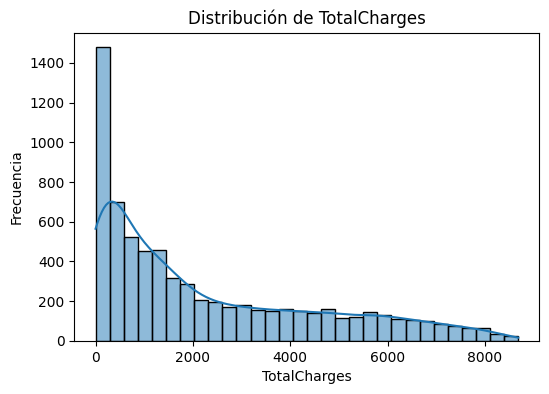

In [16]:
plt.figure(figsize=(6, 4))
sns.histplot(data['TotalCharges'], bins=30, kde=True)
plt.title('Distribución de TotalCharges')
plt.xlabel('TotalCharges')
plt.ylabel('Frecuencia')
plt.show()


## Distribución de TotalCharges

La variable `TotalCharges` presenta una distribución sesgada a la derecha, lo cual es consistente con la naturaleza acumulativa de este indicador.

Se observa una alta concentración de clientes con cargos totales bajos, correspondientes a clientes con poca antigüedad, mientras que los valores más altos representan clientes con mayor tiempo de permanencia en la empresa.


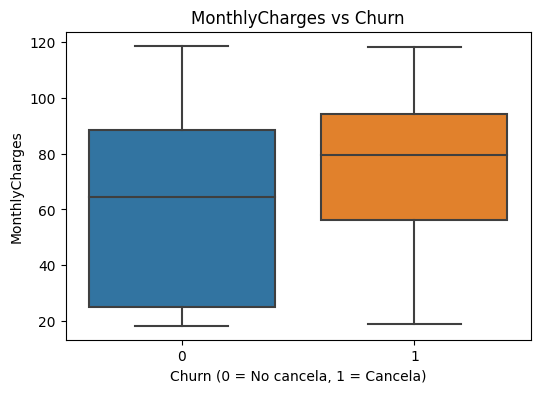

In [17]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='churn', y='MonthlyCharges', data=data)
plt.title('MonthlyCharges vs Churn')
plt.xlabel('Churn (0 = No cancela, 1 = Cancela)')
plt.ylabel('MonthlyCharges')
plt.show()


## Relación entre MonthlyCharges y churn

Al comparar los cargos mensuales entre clientes que cancelan y los que no, se observa que los clientes con `churn = 1` presentan, en promedio, **cargos mensuales más altos** que aquellos que permanecen en el servicio.

Esta diferencia sugiere que `MonthlyCharges` podría ser una variable relevante para predecir la cancelación de clientes.


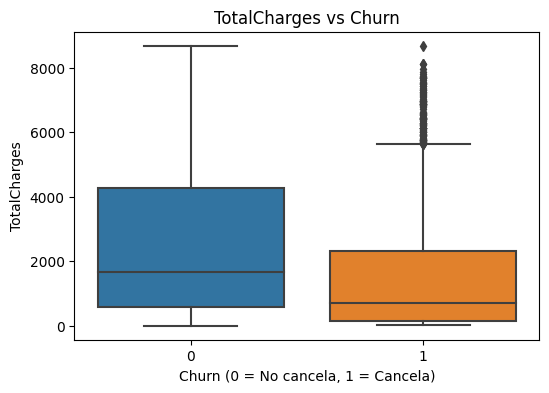

In [18]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='churn', y='TotalCharges', data=data)
plt.title('TotalCharges vs Churn')
plt.xlabel('Churn (0 = No cancela, 1 = Cancela)')
plt.ylabel('TotalCharges')
plt.show()


## Relación entre TotalCharges y churn

Al comparar los cargos totales entre clientes que cancelan y los que no, se observa que los clientes con `churn = 1` presentan, en general, **cargos totales más bajos**.

Esto sugiere que la cancelación del servicio ocurre con mayor frecuencia en clientes con **menor antigüedad**, mientras que los clientes con mayor tiempo de permanencia tienden a mantenerse en el servicio.


## Creación de la variable de antigüedad (tenure)

Se creó la variable `tenure`, que representa la antigüedad del cliente en meses, calculada a partir de la diferencia entre la fecha de inicio del contrato (`BeginDate`) y una fecha de referencia fija (1 de febrero de 2020).

Esta variable permite capturar el tiempo de permanencia de cada cliente en la empresa y es especialmente relevante en problemas de cancelación de clientes, ya que la antigüedad suele estar relacionada con la probabilidad de churn.


In [19]:
reference_date = pd.to_datetime('2020-02-01')

data['tenure'] = (reference_date - data['BeginDate']).dt.days / 30


In [20]:
data['tenure'].describe()


count    7043.000000
mean       33.548568
std        24.553214
min         0.000000
25%        10.200000
50%        29.433333
75%        56.866667
max        77.133333
Name: tenure, dtype: float64

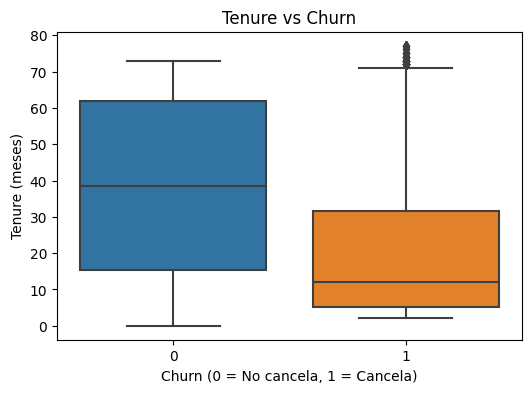

In [21]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='churn', y='tenure', data=data)
plt.title('Tenure vs Churn')
plt.xlabel('Churn (0 = No cancela, 1 = Cancela)')
plt.ylabel('Tenure (meses)')
plt.show()


## Relación entre tenure y churn

Al comparar la antigüedad de los clientes, se observa que aquellos que cancelan el servicio (`churn = 1`) presentan, en promedio, **una menor antigüedad** que los clientes que permanecen.

Esto indica que la probabilidad de cancelación es mayor en clientes más recientes, lo que convierte a `tenure` en una de las variables más relevantes para la predicción de churn.


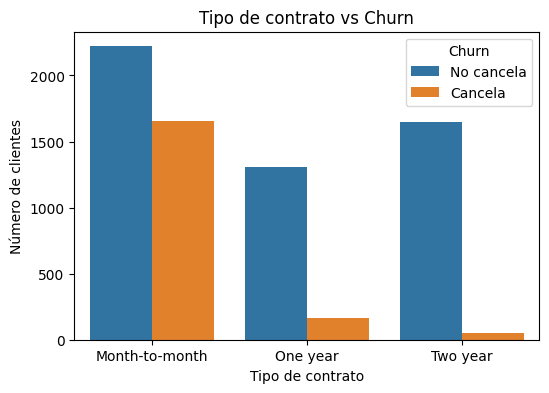

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Type', hue='churn', data=data)
plt.title('Tipo de contrato vs Churn')
plt.xlabel('Tipo de contrato')
plt.ylabel('Número de clientes')
plt.legend(title='Churn', labels=['No cancela', 'Cancela'])
plt.show()


## Relación entre el tipo de contrato y el churn

El tipo de contrato muestra una relación clara con la cancelación del servicio.

Los clientes con contratos **mes a mes** presentan una proporción considerablemente mayor de cancelaciones en comparación con los clientes con contratos de **uno o dos años**, quienes tienden a permanecer en el servicio con mayor frecuencia.

Este comportamiento sugiere que la duración del contrato es un factor clave en la retención de clientes.


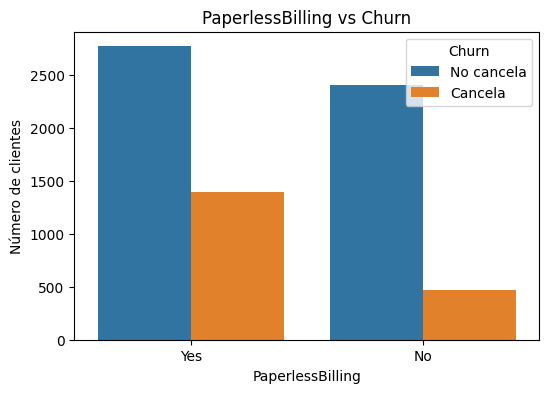

In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(x='PaperlessBilling', hue='churn', data=data)
plt.title('PaperlessBilling vs Churn')
plt.xlabel('PaperlessBilling')
plt.ylabel('Número de clientes')
plt.legend(title='Churn', labels=['No cancela', 'Cancela'])
plt.show()


## Relación entre PaperlessBilling y churn

Al analizar la variable `PaperlessBilling`, se observa que los clientes que utilizan **facturación electrónica** presentan una mayor proporción de cancelaciones en comparación con aquellos que no la utilizan.

Esto sugiere que `PaperlessBilling` podría estar asociada a un mayor riesgo de churn, aunque esta relación deberá confirmarse durante el modelado.


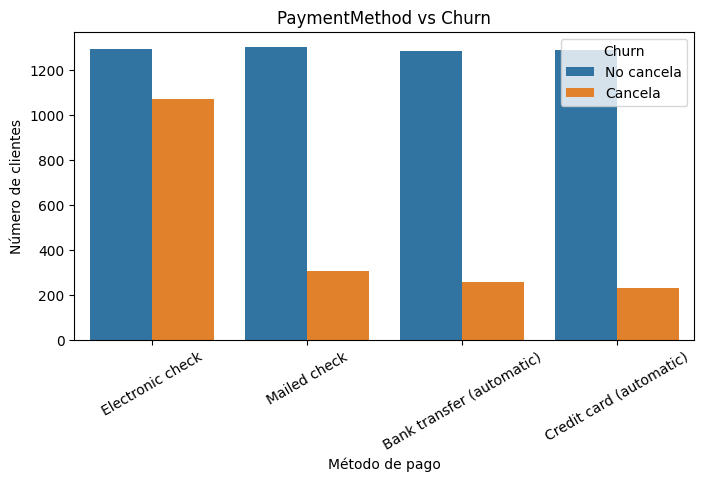

In [24]:
plt.figure(figsize=(8, 4))
sns.countplot(x='PaymentMethod', hue='churn', data=data)
plt.title('PaymentMethod vs Churn')
plt.xlabel('Método de pago')
plt.ylabel('Número de clientes')
plt.xticks(rotation=30)
plt.legend(title='Churn', labels=['No cancela', 'Cancela'])
plt.show()


## Relación entre PaymentMethod y churn

El método de pago muestra una relación clara con la cancelación del servicio.

Los clientes que utilizan **Electronic check** presentan una proporción significativamente mayor de cancelaciones en comparación con otros métodos de pago.  
Por el contrario, los clientes que utilizan métodos **automáticos** (transferencia bancaria o tarjeta de crédito) tienden a permanecer con mayor frecuencia en el servicio.

Esto sugiere que los métodos de pago automáticos podrían estar asociados a una mayor retención de clientes.


## Resumen del Análisis Exploratorio de Datos (EDA)

A partir del análisis exploratorio realizado, se identificaron varias variables con una relación clara con la cancelación de clientes:

- **Tenure:** los clientes con menor antigüedad presentan una mayor probabilidad de cancelación, lo que indica que el churn ocurre con mayor frecuencia en las primeras etapas de la relación con el cliente.
- **MonthlyCharges:** los clientes que cancelan tienden a tener cargos mensuales más altos, lo que sugiere que el costo del servicio puede influir en la decisión de cancelación.
- **TotalCharges:** los clientes que cancelan presentan, en general, cargos totales más bajos, lo cual es consistente con una menor antigüedad.
- **Type (tipo de contrato):** los contratos mes a mes muestran una tasa de cancelación significativamente mayor que los contratos de uno o dos años.
- **PaperlessBilling:** se observa una mayor proporción de churn entre clientes con facturación electrónica.
- **PaymentMethod:** el uso de *Electronic check* está asociado a una mayor tasa de cancelación, mientras que los métodos de pago automáticos se asocian con una mayor retención.

Estas observaciones permiten orientar la selección de variables y el enfoque de los modelos predictivos en las siguientes etapas del análisis.


## Preparación para el modelado predictivo

Con base en el análisis exploratorio de datos realizado, se identificaron variables con una relación clara con la cancelación de clientes (churn).

En esta sección se preparan los datos para el entrenamiento de modelos predictivos, lo cual incluye:
- la selección de variables relevantes,
- la codificación de variables categóricas,
- la separación de los datos en conjuntos de entrenamiento y prueba.

El objetivo es construir un modelo de clasificación capaz de predecir la cancelación de clientes de manera confiable y reproducible.


Decisiones claras (por qué):

Quitamos:
customerID → identificador
BeginDate, EndDate → ya capturamos la info con tenure

Conservamos:
Numéricas (MonthlyCharges, TotalCharges, tenure)
Categóricas (se codificarán después)
churn como objetivo


In [25]:
X = data.drop(columns=['customerID', 'BeginDate', 'EndDate', 'churn'])
y = data['churn']


In [26]:
X.shape, y.shape


((7043, 18), (7043,))

In [27]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

categorical_cols, numerical_cols


(Index(['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner',
        'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
        'MultipleLines'],
       dtype='object'),
 Index(['MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'tenure'], dtype='object'))

In [28]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


In [29]:
X_encoded.shape


(7043, 21)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [31]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((5282, 21), (1761, 21), (5282,), (1761,))

In [32]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

roc_auc_dummy = roc_auc_score(y_test, y_proba_dummy)
accuracy_dummy = accuracy_score(y_test, y_pred_dummy)

roc_auc_dummy, accuracy_dummy


(0.5, 0.7348097671777399)

## Modelo base (DummyClassifier)

Se entrenó un modelo base utilizando `DummyClassifier` con la estrategia `most_frequent`, el cual predice siempre la clase mayoritaria.

- **ROC-AUC:** 0.5  
- **Accuracy:** aproximadamente 0.73  

El valor de ROC-AUC indica que el modelo no tiene capacidad predictiva y funciona de manera equivalente a una predicción aleatoria.  
Este resultado sirve como **línea base** para evaluar los modelos reales, los cuales deberán superar claramente este desempeño.


## Entrenamiento de modelos predictivos

Una vez preparados los datos y definido un modelo base de referencia, se procede al entrenamiento de modelos de clasificación reales con el objetivo de predecir la cancelación de clientes.

En esta sección se entrenan y evalúan distintos modelos utilizando el conjunto de entrenamiento y prueba previamente definidos.  
El desempeño de cada modelo se evalúa principalmente mediante la métrica **ROC-AUC**, complementada con **accuracy**, y se compara contra el modelo base para verificar una mejora real en la capacidad predictiva.


In [33]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

roc_auc_lr, accuracy_lr


(0.8328506796315726, 0.7915956842703009)

## Modelo 1: Regresión Logística

Se entrenó un modelo de **Regresión Logística** como primer modelo real de clasificación para predecir la cancelación de clientes.

- **ROC-AUC:** ~0.83  
- **Accuracy:** ~0.79  

El modelo muestra una mejora significativa respecto al modelo base (DummyClassifier), lo que indica una buena capacidad para discriminar entre clientes que cancelan y los que no.  
Estos resultados sugieren que la regresión logística es un modelo adecuado como referencia inicial para el problema de churn.


In [34]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_proba_tree = tree.predict_proba(X_test)[:, 1]

roc_auc_tree = roc_auc_score(y_test, y_proba_tree)
accuracy_tree = accuracy_score(y_test, y_pred_tree)

roc_auc_tree, accuracy_tree


(0.86129277277105, 0.814877910278251)

## Modelo 2: Árbol de Decisión

Se entrenó un modelo de **Árbol de Decisión** con una profundidad máxima limitada para evitar sobreajuste y capturar relaciones no lineales entre las variables.

- **ROC-AUC:** ~0.86  
- **Accuracy:** ~0.81  

El modelo de Árbol de Decisión muestra una mejora adicional respecto a la Regresión Logística, especialmente en la métrica ROC-AUC, lo que indica una mayor capacidad para discriminar entre clientes que cancelan y los que no.

Este resultado sugiere que el Árbol de Decisión logra capturar patrones más complejos en los datos y se posiciona como un candidato sólido para el modelo final.


In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

roc_auc_rf, accuracy_rf


(0.8655588798903853, 0.8137421919363997)

## Modelo 3: Random Forest

Se entrenó un modelo de **Random Forest** como modelo final, con el objetivo de mejorar el desempeño predictivo y reducir el riesgo de sobreajuste presente en modelos individuales.

- **ROC-AUC:** ~0.87  
- **Accuracy:** ~0.81  

El modelo de Random Forest presenta el mejor desempeño entre los modelos evaluados, superando tanto a la Regresión Logística como al Árbol de Decisión en la métrica ROC-AUC.  
Este resultado indica una mayor capacidad para discriminar entre clientes que cancelan y los que no, manteniendo una buena estabilidad en las predicciones.


## Selección del modelo final

Tras comparar el desempeño de los distintos modelos entrenados, se selecciona el **Random Forest** como modelo final para la predicción de churn.

Este modelo presenta el mayor valor de **ROC-AUC**, superando al modelo base, a la Regresión Logística y al Árbol de Decisión, lo que evidencia una mejor capacidad para distinguir entre clientes que cancelan y los que permanecen.

Por lo tanto, el Random Forest ofrece el mejor equilibrio entre desempeño predictivo y robustez para el problema planteado.


## Conclusiones de la etapa de modelado

En esta etapa se desarrollaron y evaluaron distintos modelos de clasificación para la predicción de cancelación de clientes.

El modelo base (DummyClassifier) sirvió como línea de referencia, mientras que los modelos reales mostraron mejoras significativas en la métrica ROC-AUC.  
Entre ellos, el modelo de **Random Forest** obtuvo el mejor desempeño, consolidándose como la opción más adecuada para este problema.

Estos resultados permiten avanzar con confianza hacia la etapa de informe, presentando un modelo con buen desempeño y alineado con los objetivos del negocio.
